## 1. Loading the Data
*Carregando os dados*

Loading the 5 main Olist datasets into Pandas DataFrames for analysis.

Os 5 principais datasets da Olist são carregados como DataFrames do Pandas para análise.

In [6]:
import pandas as pd

# Loading datasets
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [7]:
# Exploring orders dataset and strucure
# Explorando dimensões e estruturas do dataset orders

print("Orders shape: ", orders.shape)
print("\nColumn types:")
print(orders.dtypes)

Orders shape:  (99441, 8)

Column types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


In [8]:
# Previewing the first 5 rows of orders
# Visualizando as primeiras 5 linhas do dataset orders

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
# Checking for missing values in orders dataset
# Verificando valores nulos no dataset de pedidos

orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## 2. Descriptive Statistics and Data Types
*Estatísticas descritivas e tipos de dados*

Exploring the statistical summary and structure of the main datasets.

Explorando o resumo estatístico e a estrutura dos principais datasets.

In [10]:
# Statistical summary of orders dataset
# Resumo estatístico do dataset orders

orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [11]:
# Detailed info about orders dataset structure
# Informações detalhadas sobre a estrutura do dataset orders

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [13]:
# Distribution of order statuses
# Distribuição dos status dos pedidos

orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [15]:
# Exploring customers dataset
# Explorando o dataset customers

print("Customers shape:", customers.shape)
print("\nMissing values:")
print(customers.isnull().sum())
print("\nTop 10 states by number of customers:")
print(customers['customer_state'].value_counts().head(10))

Customers shape: (99441, 5)

Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Top 10 states by number of customers:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


## 3. Orders Analysis
*Análise de Pedidos*

Analyzing order distribution by status and visualizing the results.

Análise da distribuição de pedidos por status e visualização dos resultados.

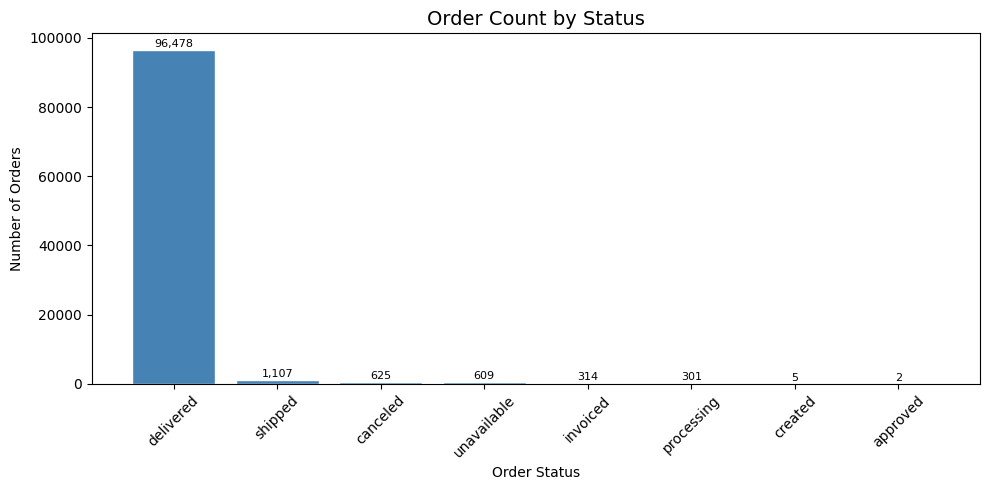

In [20]:
import matplotlib.pyplot as plt

# Bar chart: order count by status
# Gráfico de barras: quantidade de pedidos por status
status_counts = orders['order_status'].value_counts()

plt.figure(figsize=(10,5))
bars = plt.bar(status_counts.index, status_counts.values, color='steelblue', edgecolor='white')
plt.title('Order Count by Status', fontsize=14)
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

# Adding labels on top of each bar
# Adicionando rótulos no topo de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 200, f'{int(height):,}', ha='center', va='bottom', fontsize=8)


plt.tight_layout()
plt.savefig('../dashboards/screenshots/order_status.png')
plt.show()

In [21]:
# Order count and percentage by status using groupby
# Contagem e percentual de pedidos por status usando groupby

status_summary = orders.groupby('order_status').size().reset_index(name='count')
status_summary['percentage'] = (status_summary['count'] / len(orders) * 100).round(2)
status_summary = status_summary.sort_values('count', ascending=False)
status_summary

,order_status,count,percentage
3,delivered,96478,97.02
6,shipped,1107,1.11
1,canceled,625,0.63
7,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
2,created,5,0.01
0,approved,2,0.00


## 4. Revenue Analysis Over Time
*Análise de Receita ao Longo do Tempo*

Analyzing monthly revenue trends using order payments data.

Análise da tendência de receita mensal usando os dados de pagamentos.

In [22]:
# Merging orders with payments to get revenue data
# Unindo pedidos com pagamentos para obter dados de receita
orders_payments = orders.merge(payments, on='order_id', how='inner')

# Converting purchase timestamp to datetime
# Convertendo timestamp de compra para datetime
orders_payments['order_purchase_timestamp'] = pd.to_datetime(orders_payments['order_purchase_timestamp'])

# Montlhy revenue
# Receita mensal
monthly_revenue = (
    orders_payments
    .set_index('order_purchase_timestamp')
    .resample('ME')['payment_value']
    .sum()
    .reset_index()
)

monthly_revenue.head()

,order_purchase_timestamp,payment_value
0,2016-09-30,252.24
1,2016-10-31,59090.48
2,2016-11-30,0.00
3,2016-12-31,19.62
4,2017-01-31,138488.04


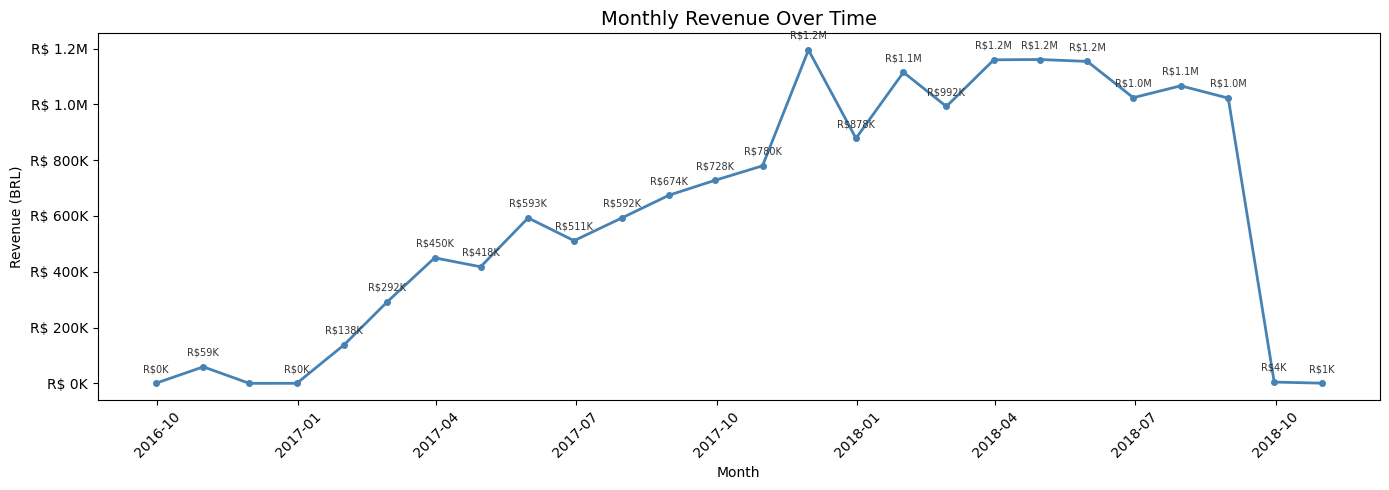

In [25]:
# Line chart: monthly revenue over time
# Gráfico de linha: receita mensal ao longo do tempo
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(monthly_revenue['order_purchase_timestamp'],
        monthly_revenue['payment_value'],
        color='steelblue', linewidth=2, marker='o', markersize=4)

# Formatting Y axis as currency (no scientific notation)
# Formatando eixo Y como moeda (sem notação científica)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f}M' if x >= 1_000_000
                      else f'R$ {x/1_000:.0f}K')
)

# Adding value labels on each data point
# Adicionando rótulos em cada ponto de dado
for _, row in monthly_revenue.iterrows():
    value = row['payment_value']
    if value > 0:
        label = f'R${value/1_000_000:.1f}M' if value >= 1_000_000 else f'R${value/1_000:.0f}K'
        ax.annotate(label,
                    xy=(row['order_purchase_timestamp'], value),
                    xytext=(0,8), textcoords='offset points',
                    ha='center', fontsize=7, color='#333333')

ax.set_title('Monthly Revenue Over Time', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../dashboards/screenshots/monthly_revenue.png')
plt.show()

## 5. Revenue by Product Category
*Receita por Categoria de Produto*

Merging orders, order items and products to analyze revenue by category.

Unindo pedidos, itens e produtos para analisar receita por categoria.

In [26]:
# Loading products and category translations datasets
# Carregando datasets products e category translations
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
category_translation = pd.read_csv('../data/raw/product_category_name_translation.csv')

# Merging all datasets
# Unindo todos os datasets
orders_items_products = (
    orders
    .merge(order_items, on='order_id', how='inner')
    .merge(payments, on='order_id', how='inner')
    .merge(products, on='product_id', how='inner')
    .merge(category_translation, on='product_category_name', how='left')
)

print("Merged dataset shape:", orders_items_products.shape)
orders_items_products.head()

Merged dataset shape: (117601, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


In [28]:
# Top 10 categories by total revenue
# Top 10 categorias por receita total
top_categories = (
    orders_items_products
    .groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_categories.columns = ['category', 'revenue']
top_categories['revenue_formatted'] = top_categories['revenue'].apply(
    lambda x: f'R${x/1_000_000:.2f}M'
)

top_categories

,category,revenue,revenue_formatted
0,bed_bath_table,1712553.67,R$1.71M
1,health_beauty,1657373.12,R$1.66M
2,computers_accessories,1585330.45,R$1.59M
3,furniture_decor,1430176.39,R$1.43M
4,watches_gifts,1429216.68,R$1.43M
5,sports_leisure,1392127.56,R$1.39M
6,housewares,1094758.13,R$1.09M
7,auto,852294.33,R$0.85M
8,garden_tools,838280.75,R$0.84M
9,cool_stuff,779698.00,R$0.78M


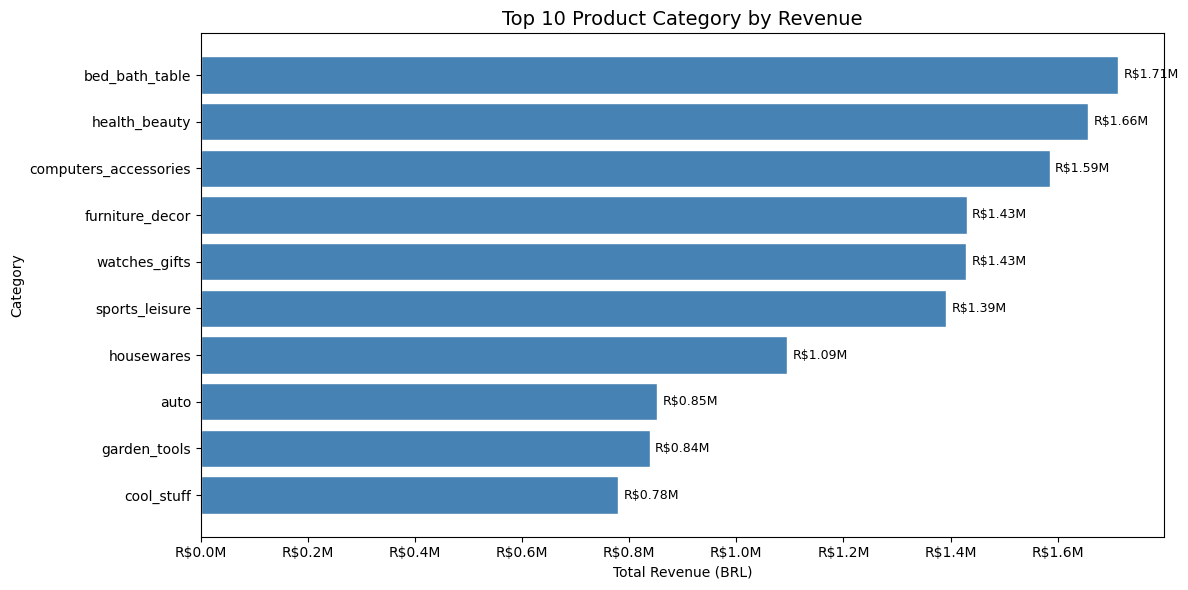

In [29]:
# Bar chart: top 10 categories by revenue
# Gráfico de barras: top 10 categorias por receita
fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(top_categories['category'][::-1],
               top_categories['revenue'][::-1],
               color='steelblue', edgecolor='white')

# Adding value labels
# Adicionando rótulos de valor
for bar, value in zip(bars, top_categories['revenue'][::-1]):
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'R${value/1_000_000:.2f}M', va='center', fontsize=9)
    
ax.set_title('Top 10 Product Category by Revenue', fontsize=14)
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Category')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'R${x/1_000_000:.1f}M')
)
plt.tight_layout()
plt.savefig('../dashboards/screenshots/top_categories_revenue.png')
plt.show()

## 6. Top 10 Sellers by Order Volume
*Top 10 Vendedores por Volume de Pedidos*

Identifying the most active sellers on the Olist platform by number of orders.

Identificando os vendedores mais ativos na plataforma Olist por número de pedidos.

In [ ]:
# Loading sellers dataset
# Carregando dataset sellers
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')

# Merging orders with order_items and sellers
# Unindo orders com order_items e sellers
orders_sellers = (
    orders
    .merge(order_items, on='order_id', how='inner')
    .merge(sellers, on='seller_id', how='inner')
)

# Top 10 sellers by order volume
# Top 10 vendedores por volume de pedidos
top_sellers = (
    orders_sellers
    .groupby('seller_id')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_sellers.columns = ['seller_id','order_count']
top_sellers['seller_short'] = top_sellers['seller_id'].str[:8] + '...'
top_sellers